# Prompting으로 PyTorch 회귀 문제 해결하기

## 실습 목표

이 노트북은 `Day1_2_NeuralNet.ipynb`의 **Neural Network 회귀 예제**를 바탕으로 합니다.

수업 예제에서는 다음 문제를 PyTorch로 직접 해결했습니다.

\[
y = x_1^2 + x_2^2
\]

이번 실습에서는 같은 문제를 **Web GPT / ChatGPT에게 좋은 프롬프트로 요청해서 해결하는 과정**을 연습합니다.

### 오늘 배울 것

1. 좋은 프롬프트와 안 좋은 프롬프트의 차이 이해하기
2. GPT에게 코드를 한 번에 달라고 하기보다, 단계별로 문제를 나누어 요청하기
3. GPT가 준 코드를 그대로 믿지 않고 실행, 오류 확인, 수정 요청하기
4. Kaggle의 회귀 문제 2개를 GPT와 함께 풀어볼 준비하기

> 이 실습은 classification이 아니라 **regression(숫자 예측)** 중심입니다.

# 1. 좋은 Prompt vs 안 좋은 Prompt

GPT에게 코딩 문제를 물어볼 때는 “뭘 해줘”만 쓰는 것보다,  
**문제 상황, 데이터 형태, 목표, 제약 조건, 원하는 출력**을 함께 알려주는 것이 좋습니다.

## 1.1 안 좋은 Prompt 예시

아래 프롬프트는 너무 짧고 모호합니다.

> PyTorch로 모델 만들어줘.

### 왜 안 좋을까?

- 어떤 데이터를 쓰는지 모릅니다.
- 입력과 출력의 shape를 모릅니다.
- 회귀 문제인지 분류 문제인지 모릅니다.
- 어떤 loss function을 써야 하는지 알 수 없습니다.
- 학습 결과를 어떻게 확인해야 하는지 모릅니다.

## 1.2 좋은 Prompt 예시

아래 프롬프트는 문제를 훨씬 구체적으로 설명합니다.

> 나는 PyTorch 초보자야.  
> 입력 데이터 `x`는 shape이 `(1000, 2)`이고, 각 값은 -1부터 1 사이의 실수야.  
> 정답 `y`는 `y = x1^2 + x2^2`로 계산되는 회귀 문제야.  
> 800개는 train, 200개는 test로 나눠서 사용할 거야.  
> 간단한 Nueral Net으로 학습하는 코드를 줘.
> 각 코드 블록마다 초보자가 이해할 수 있도록 주석을 달아줘.


## 1.3 Prompt 작성 공식

아래 구조를 기억하면 좋습니다.

```text
[역할] 너는 PyTorch를 잘 가르치는 튜터야.

[상황] 나는 PyTorch 초보자이고, 수업에서 신경망 회귀 예제를 배우고 있어.

[데이터] 입력 x는 shape이 (...), 정답 y는 ...

[목표] ...를 예측하는 모델을 만들고 싶어.

[조건] train/test split, loss function, optimizer, epoch 수 등

[출력 형식] 코드와 설명을 단계별로 작성해줘.
```

# 2. 실습 문제: GPT에게 Neural Network 회귀 예제 해결 요청하기

이번 실습 문제는 다음 함수 값을 예측하는 것입니다.

\[
y = x_1^2 + x_2^2
\]

입력은 2차원 좌표 `(x1, x2)`이고, 출력은 하나의 실수 `y`입니다.

즉, 이것은 **classification이 아니라 regression 문제**입니다.

In [ ]:
# 기본 라이브러리 불러오기

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# 재현성을 위한 seed 고정
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 device:", device)

사용 device: cuda


In [ ]:
# 데이터 생성

# x는 1000개의 2차원 입력값입니다.
# 각 값은 -1부터 1 사이의 실수입니다.
x = torch.rand(1000, 2) * 2 - 1

# y = x1^2 + x2^2
y = (x[:, 0] ** 2 + x[:, 1] ** 2).unsqueeze(1)

print("x shape:", x.shape)
print("y shape:", y.shape)
print("x 예시:", x[:5])
print("y 예시:", y[:5])

x shape: torch.Size([1000, 2])
y shape: torch.Size([1000, 1])
x 예시: tensor([[ 0.7645,  0.8300],
        [-0.2343,  0.9186],
        [-0.2191,  0.2018],
        [-0.4869,  0.5873],
        [ 0.8815, -0.7336]])
y 예시: tensor([[1.2734],
        [0.8987],
        [0.0887],
        [0.5819],
        [1.3153]])


In [ ]:
# train/test 데이터 분리

x_train = x[:800].to(device)
y_train = y[:800].to(device)

x_test = x[800:].to(device)
y_test = y[800:].to(device)

print("train:", x_train.shape, y_train.shape)
print("test :", x_test.shape, y_test.shape)

train: torch.Size([800, 2]) torch.Size([800, 1])
test : torch.Size([200, 2]) torch.Size([200, 1])


## 2.1 GPT에게 요청할 Prompt 작성하기

아래 빈칸에 여러분이 GPT에게 보낼 프롬프트를 직접 작성해보세요.

### 미션

GPT에게 다음을 요청해야 합니다.

- PyTorch로 회귀 모델 만들기
- 입력 shape: `(1000, 2)`
- 출력 shape: `(1000, 1)`
- 정답 함수: `y = x1^2 + x2^2`
- train 800개, test 200개
- Shallow 모델과 Deep 모델 비교
- MSELoss 사용
- 학습 loss 또는 test loss 시각화

In [ ]:
my_prompt = """
여기에 GPT에게 보낼 좋은 프롬프트를 작성하세요.

예시를 그대로 복사하지 말고,
데이터, 목표, 조건, 출력 형식을 직접 포함해보세요.
"""

print(my_prompt)

## 2.2 GPT가 준 코드 검토 체크리스트

GPT가 코드를 작성해주면, 바로 실행하기 전에 아래를 확인하세요.

- `x_train`, `y_train`, `x_test`, `y_test`를 실제로 사용하고 있는가?
- 모델의 입력 차원이 `2`인가?
- 모델의 출력 차원이 `1`인가?
- 회귀 문제인데 `CrossEntropyLoss`를 쓰고 있지는 않은가?
- 회귀 문제에 맞게 `MSELoss` 또는 `L1Loss`를 쓰고 있는가?
- 학습 전에 `optimizer.zero_grad()`를 호출하는가?
- `loss.backward()`와 `optimizer.step()`이 들어 있는가?
- 평가할 때 `torch.no_grad()`를 사용하는가?

# 3. 기준 코드: Shallow Neural Network

아래 코드는 GPT에게 요청했을 때 기대할 수 있는 기준 답안입니다.  
여러분이 GPT에게 받은 코드와 비교해보세요.

In [ ]:
class ShallowNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 4),
            nn.ReLU(),
            nn.Linear(4, 1)
        )

    def forward(self, x):
        return self.net(x)


shallow_model = ShallowNN().to(device)
criterion = nn.MSELoss()
optimizer = optim.SGD(shallow_model.parameters(), lr=0.1)

num_epochs = 100
shallow_test_losses = []

for epoch in range(num_epochs):
    shallow_model.train()
    pred = shallow_model(x_train)
    loss = criterion(pred, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    shallow_model.eval()
    with torch.no_grad():
        test_pred = shallow_model(x_test)
        test_loss = criterion(test_pred, y_test)

    if (epoch + 1) % 10 == 0:
        shallow_test_losses.append(test_loss.item())
        print(f"Epoch {epoch+1:3d} | Test Loss: {test_loss.item():.5f}")

Epoch  10 | Test Loss: 0.17676
Epoch  20 | Test Loss: 0.17178
Epoch  30 | Test Loss: 0.16891
Epoch  40 | Test Loss: 0.16702
Epoch  50 | Test Loss: 0.16561
Epoch  60 | Test Loss: 0.16439
Epoch  70 | Test Loss: 0.16326
Epoch  80 | Test Loss: 0.16216
Epoch  90 | Test Loss: 0.16110
Epoch 100 | Test Loss: 0.16012


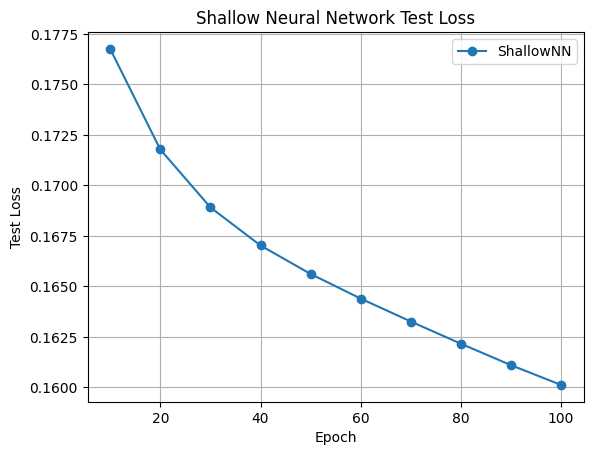

In [ ]:
epochs = list(range(10, num_epochs + 1, 10))

plt.plot(epochs, shallow_test_losses, marker="o", label="ShallowNN")
plt.xlabel("Epoch")
plt.ylabel("Test Loss")
plt.title("Shallow Neural Network Test Loss")
plt.legend()
plt.grid(True)
plt.show()

# 4. GPT에게 디버깅 요청하기

코드를 실행하다가 오류가 나면, 오류 메시지만 던지지 말고  
**현재 코드, 오류 메시지, 원하는 결과**를 함께 알려주는 것이 좋습니다.

## 안 좋은 디버깅 Prompt

> 에러 났어. 고쳐줘.

## 좋은 디버깅 Prompt

```text
아래 PyTorch 코드에서 오류가 발생했어.

[내 코드]
```python
여기에 오류가 난 코드 붙여넣기
```

[오류 메시지]
```text
여기에 전체 오류 메시지 붙여넣기
```

[내가 원하는 결과]
x_train shape은 (800, 2), y_train shape은 (800, 1)이야.
MSELoss를 사용해서 회귀 모델을 학습하고 싶어.
오류 원인을 설명하고, 수정된 코드를 제시해줘.
```

# 5. GPT에게 성능 개선 요청하기

모델이 잘 학습되지 않는다면 다음과 같이 요청할 수 있습니다.

```text
현재 PyTorch 회귀 모델의 test loss가 잘 줄어들지 않아.
데이터는 y = x1^2 + x2^2이고, 입력은 2차원, 출력은 1차원이야.

현재 모델:
- Linear(2, 4)
- ReLU
- Linear(4, 1)

optimizer는 SGD(lr=0.1), loss는 MSELoss를 사용하고 있어.

성능을 개선하기 위해 시도할 수 있는 방법을
1. 모델 구조
2. optimizer
3. learning rate
4. epoch 수
5. 데이터 시각화
관점에서 설명해줘.
그리고 수정된 PyTorch 코드를 작성해줘.
```

# 6. 직접 해보기: GPT 도움을 받아 모델 개선하기

아래 셀에 GPT가 제안한 개선 코드를 붙여넣고 실행해보세요.

실험 아이디어 예시:

- hidden layer 크기 바꾸기: 4 → 16 → 64
- layer 개수 바꾸기
- `SGD` 대신 `Adam` 사용하기
- learning rate 바꾸기
- epoch 수 늘리기

In [ ]:
# TODO:
# GPT가 제안한 개선 코드를 여기에 붙여넣고 실행해보세요.

# 예시 시작 코드
class MyImprovedNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32),
            nn.ReLU(),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)


# 직접 학습 코드를 작성하거나 GPT에게 요청해서 완성해보세요.

# 8. Kaggle 문제 1: House Prices - Advanced Regression Techniques

## 문제 요약

Kaggle의 **House Prices - Advanced Regression Techniques**는  
Ames, Iowa 주택 데이터의 여러 특징을 사용해서 **집값 SalePrice를 예측하는 회귀 문제**입니다.

- 문제 유형: Regression
- 목표: 주택 가격 `SalePrice` 예측
- 관련 수업 내용:
  - train/test 데이터 분리
  - feature와 label 구분
  - loss를 줄이는 모델 학습
  - 예측값 제출 파일 만들기

## GPT에게 보낼 Prompt 예시

```text
나는 PyTorch와 머신러닝을 배우는 초보자야.
Kaggle의 House Prices - Advanced Regression Techniques 문제를 풀고 싶어.

~~~~~~~~~~~~~~~~~~~~~~~~~~
```

Kaggle 링크: https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques

# 9. Kaggle 문제 2: Bike Sharing Demand

## 문제 요약

Kaggle의 **Bike Sharing Demand**는  
날짜, 시간, 날씨, 계절 등의 정보를 사용해서 **자전거 대여 수요를 예측하는 회귀 문제**입니다.

- 문제 유형: Regression
- 목표: 특정 시간대의 자전거 대여량 예측
- 관련 수업 내용:
  - 입력 feature로부터 숫자 label 예측
  - loss function을 사용한 모델 평가
  - 데이터 시각화로 패턴 확인하기

## GPT에게 보낼 Prompt 예시

```text
나는 PyTorch와 데이터 시각화를 배우는 초보자야.
Kaggle의 Bike Sharing Demand 문제를 GPT 도움을 받아 풀고 싶어.

이 문제는 날짜, 시간, 날씨 정보를 사용해서 자전거 대여량 count를 예측하는 회귀 문제야.
수업에서는 y = x1^2 + x2^2를 예측하는 PyTorch 회귀 모델과 matplotlib 시각화를 배웠어.

다음 순서로 초보자용 코드를 작성해줘:
1. train.csv, test.csv 불러오기
2. datetime에서 hour, day, month 같은 feature 만들기
3. count와 hour, weather, temperature 관계를 시각화하기
4. train/validation 데이터 나누기
5. RandomForestRegressor 또는 간단한 Neural Network로 baseline 모델 만들기
6. 예측 결과로 submission.csv 만들기

각 코드 블록에는 주석을 달아줘.
그리고 왜 그 단계를 하는지도 간단히 설명해줘.
```

## 실습 메모

이 문제는 시간 정보와 날씨 정보가 포함되어 있어서  
`Day1_3_DataVisualization.ipynb`에서 배운 시각화 내용과도 잘 연결됩니다.

Kaggle 링크: https://www.kaggle.com/competitions/bike-sharing-demand